      track_id  cluster
1273      2040        2
1284      2068        2
1286      2071        2
1298      2090        2
1321      2142        2


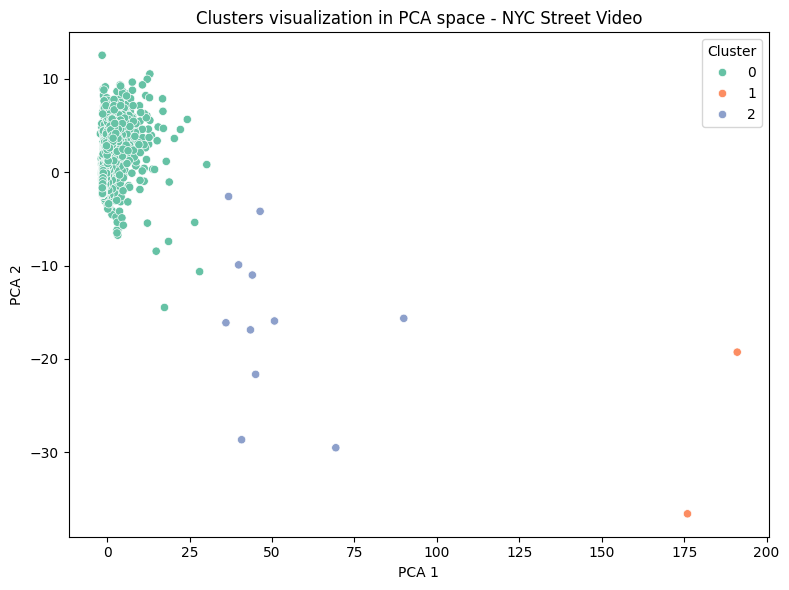

In [1]:
# K means inference
import pandas as pd
from joblib import load
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# --- Cargar features del nuevo video ---
features = pd.read_csv("features_nyc.csv")

# --- Preprocesamiento ---
features = features[features["total_points"] >= 10]
clean_features = features.dropna().reset_index(drop=True)
track_ids = clean_features["track_id"]
X_test = clean_features.drop(columns=["track_id"])

# --- Cargar scaler y transformar ---
scaler = load("scaler_kmeans.joblib")
X_test_scaled = scaler.transform(X_test)

# --- Cargar modelo KMeans y predecir ---
kmeans = load("modelo_kmeans.joblib")
cluster_labels = kmeans.predict(X_test_scaled)

# --- Juntar resultados ---
df_resultado = pd.DataFrame({
    "track_id": track_ids,
    "cluster": cluster_labels
})

# --- Unir con features originales si quieres ver más información ---
df_clusterizado = pd.merge(clean_features, df_resultado, on="track_id")

# --- Guardar resultados (opcional) ---
df_clusterizado.to_csv("cluster_result_nyc_street.csv", index=False)

# --- Mostrar ejemplo de tracks sospechosos (por ejemplo, cluster 2) ---
sospechosos = df_clusterizado[df_clusterizado["cluster"] == 2]
print(sospechosos[["track_id", "cluster"]].head())

# Cargar PCA entrenado
pca = load("pca_modelo.joblib")

# Transformar los features escalados (ya hiciste el scaler antes)
X_test_pca = pca.transform(X_test_scaled)

# Agregar las componentes al dataframe
df_resultado['pca_1'] = X_test_pca[:, 0]
df_resultado['pca_2'] = X_test_pca[:, 1]

# Visualizar
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_resultado, x='pca_1', y='pca_2', hue='cluster', palette='Set2')
plt.title("Clusters visualization in PCA space - NYC Street Video")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()



In [2]:
import numpy as np
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# --- 1. Percentage of Class 1 ---
key_class = 1 
total_points = len(df_resultado)
class1_points = np.sum(df_resultado["cluster"] == key_class)
perc_class1 = 100 * class1_points / total_points

print(f"Cluster {key_class} (suspicious) represents {perc_class1:.2f}% of all trajectories.")


# --- 2. Internal validation metrics ---
silhouette = silhouette_score(X_test_scaled, cluster_labels)
davies_bouldin = davies_bouldin_score(X_test_scaled, cluster_labels)
calinski = calinski_harabasz_score(X_test_scaled, cluster_labels)

print(f"\nSilhouette score: {silhouette:.4f}  (higher = better separation)")
print(f"Davies–Bouldin index: {davies_bouldin:.4f}  (lower = better)")
print(f"Calinski–Harabasz index: {calinski:.4f}  (higher = better)")


Cluster 1 (suspicious) represents 0.03% of all trajectories.

Silhouette score: 0.9042  (higher = better separation)
Davies–Bouldin index: 0.8577  (lower = better)
Calinski–Harabasz index: 2237.3004  (higher = better)


      track_id  cluster
1243      1952        2
3648      5784        2
4636      7379        2
5011      7959        2
6399     10282        2


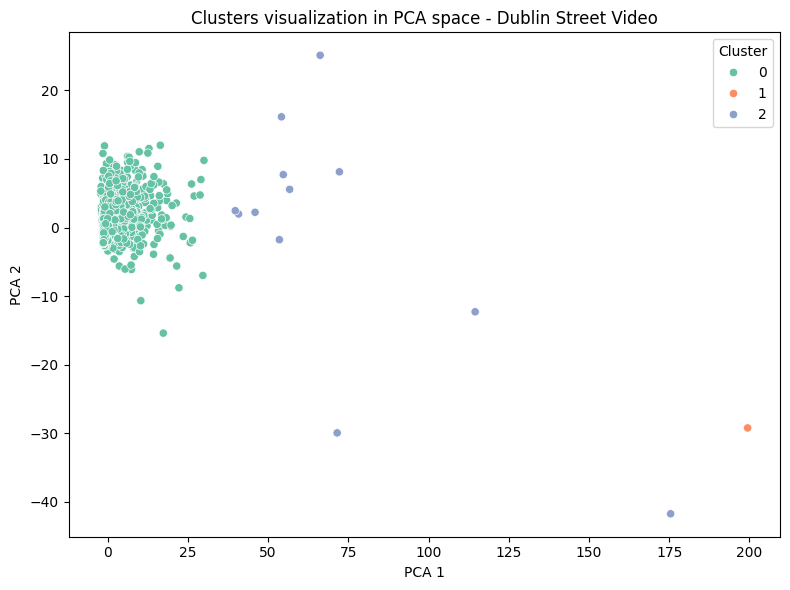

In [3]:
# K means inference
import pandas as pd
from joblib import load
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# --- Cargar features del nuevo video ---
features = pd.read_csv("features_dublin.csv")

# --- Preprocesamiento ---
features = features[features["total_points"] >= 10]
clean_features = features.dropna().reset_index(drop=True)
track_ids = clean_features["track_id"]
X_test = clean_features.drop(columns=["track_id"])

# --- Cargar scaler y transformar ---
scaler = load("scaler_kmeans.joblib")
X_test_scaled = scaler.transform(X_test)

# --- Cargar modelo KMeans y predecir ---
kmeans = load("modelo_kmeans.joblib")
cluster_labels = kmeans.predict(X_test_scaled)

# --- Juntar resultados ---
df_resultado = pd.DataFrame({
    "track_id": track_ids,
    "cluster": cluster_labels
})

# --- Unir con features originales si quieres ver más información ---
df_clusterizado = pd.merge(clean_features, df_resultado, on="track_id")

# --- Guardar resultados (opcional) ---
df_clusterizado.to_csv("cluster_result_dublin_street.csv", index=False)

# --- Mostrar ejemplo de tracks sospechosos (por ejemplo, cluster 2) ---
sospechosos = df_clusterizado[df_clusterizado["cluster"] == 2]
print(sospechosos[["track_id", "cluster"]].head())

# Cargar PCA entrenado
pca = load("pca_modelo.joblib")

# Transformar los features escalados (ya hiciste el scaler antes)
X_test_pca = pca.transform(X_test_scaled)

# Agregar las componentes al dataframe
df_resultado['pca_1'] = X_test_pca[:, 0]
df_resultado['pca_2'] = X_test_pca[:, 1]

# Visualizar
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_resultado, x='pca_1', y='pca_2', hue='cluster', palette='Set2')
plt.title("Clusters visualization in PCA space - Dublin Street Video")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


In [4]:
import numpy as np
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# --- 1. Percentage of Class 1 ---
key_class = 1 
total_points = len(df_resultado)
class1_points = np.sum(df_resultado["cluster"] == key_class)
perc_class1 = 100 * class1_points / total_points

print(f"Cluster {key_class} (suspicious) represents {perc_class1:.2f}% of all trajectories.")


# --- 2. Internal validation metrics ---
silhouette = silhouette_score(X_test_scaled, cluster_labels)
davies_bouldin = davies_bouldin_score(X_test_scaled, cluster_labels)
calinski = calinski_harabasz_score(X_test_scaled, cluster_labels)

print(f"\nSilhouette score: {silhouette:.4f}  (higher = better separation)")
print(f"Davies–Bouldin index: {davies_bouldin:.4f}  (lower = better)")
print(f"Calinski–Harabasz index: {calinski:.4f}  (higher = better)")

Cluster 1 (suspicious) represents 0.01% of all trajectories.

Silhouette score: 0.9378  (higher = better separation)
Davies–Bouldin index: 0.5631  (lower = better)
Calinski–Harabasz index: 2319.8496  (higher = better)


     track_id  cluster
269       407        2
407       631        2
864      1332        2
876      1347        2
921      1422        2


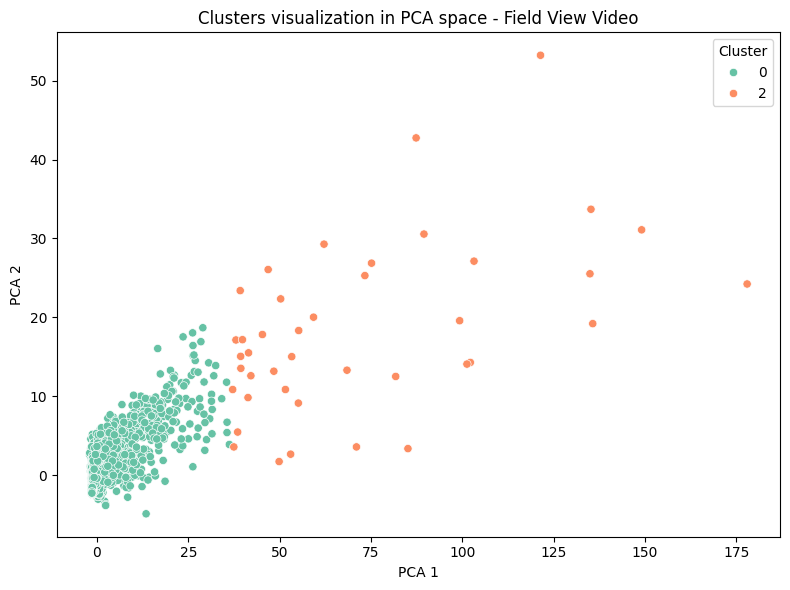

In [5]:
# K means inference
import pandas as pd
from joblib import load
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# --- Cargar features del nuevo video ---
features = pd.read_csv("features_field.csv")

# --- Preprocesamiento ---
features = features[features["total_points"] >= 10]
clean_features = features.dropna().reset_index(drop=True)
track_ids = clean_features["track_id"]
X_test = clean_features.drop(columns=["track_id"])

# --- Cargar scaler y transformar ---
scaler = load("scaler_kmeans.joblib")
X_test_scaled = scaler.transform(X_test)

# --- Cargar modelo KMeans y predecir ---
kmeans = load("modelo_kmeans.joblib")
cluster_labels = kmeans.predict(X_test_scaled)

# --- Juntar resultados ---
df_resultado = pd.DataFrame({
    "track_id": track_ids,
    "cluster": cluster_labels
})

# --- Unir con features originales si quieres ver más información ---
df_clusterizado = pd.merge(clean_features, df_resultado, on="track_id")

# --- Guardar resultados (opcional) ---
df_clusterizado.to_csv("cluster_result_field_view.csv", index=False)

# --- Mostrar ejemplo de tracks sospechosos (por ejemplo, cluster 2) ---
sospechosos = df_clusterizado[df_clusterizado["cluster"] == 2]
print(sospechosos[["track_id", "cluster"]].head())

# Cargar PCA entrenado
pca = load("pca_modelo.joblib")

# Transformar los features escalados (ya hiciste el scaler antes)
X_test_pca = pca.transform(X_test_scaled)

# Agregar las componentes al dataframe
df_resultado['pca_1'] = X_test_pca[:, 0]
df_resultado['pca_2'] = X_test_pca[:, 1]

# Visualizar
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_resultado, x='pca_1', y='pca_2', hue='cluster', palette='Set2')
plt.title("Clusters visualization in PCA space - Field View Video")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


In [6]:
import numpy as np
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# --- 1. Percentage of Class 1 ---
key_class = 1 
total_points = len(df_resultado)
class1_points = np.sum(df_resultado["cluster"] == key_class)
perc_class1 = 100 * class1_points / total_points

print(f"Cluster {key_class} (suspicious) represents {perc_class1:.2f}% of all trajectories.")


# --- 2. Internal validation metrics ---
silhouette = silhouette_score(X_test_scaled, cluster_labels)
davies_bouldin = davies_bouldin_score(X_test_scaled, cluster_labels)
calinski = calinski_harabasz_score(X_test_scaled, cluster_labels)

print(f"\nSilhouette score: {silhouette:.4f}  (higher = better separation)")
print(f"Davies–Bouldin index: {davies_bouldin:.4f}  (lower = better)")
print(f"Calinski–Harabasz index: {calinski:.4f}  (higher = better)")

Cluster 1 (suspicious) represents 0.00% of all trajectories.

Silhouette score: 0.9197  (higher = better separation)
Davies–Bouldin index: 0.6677  (lower = better)
Calinski–Harabasz index: 3783.7419  (higher = better)
